# 01 - Data Exploration

Raw and processed data for the vegetable price forecasting project: prices (2000-2025), diesel fuel prices (2015-2025), and district-wise weather (2013-2026). This notebook is exploratory only - production logic lives in `src/`, per CLAUDE.md.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.io import load_config

config = load_config()
config['vegetables']

['carrot', 'brinjal', 'pumpkin', 'cabbage', 'snake_gourd', 'leeks']

## Raw sources

In [3]:
prices = pd.read_csv('../data/raw/vegetable_prices/vegetable_prices.csv', parse_dates=['week_start'])
fuel = pd.read_csv('../data/raw/fuel/fuel_data_weekly.csv', parse_dates=['date'])
weather = pd.read_csv('../data/raw/weather/weather.csv', parse_dates=['week_start_date'])

print(prices.shape, fuel.shape, weather.shape)
prices.head()

(8184, 4) (604, 2) (16425, 4)


,vegetable,week_start,wholesale_price,retail_price
0,BRINJALS,2000-01-03,19.20,40.00
1,CABBAGE,2000-01-03,14.67,35.79
2,CARROT,2000-01-03,37.67,57.21
3,LEEKS,2000-01-03,27.27,43.11
4,PUMPKIN,2000-01-03,7.07,25.49


## Retail price trend per vegetable

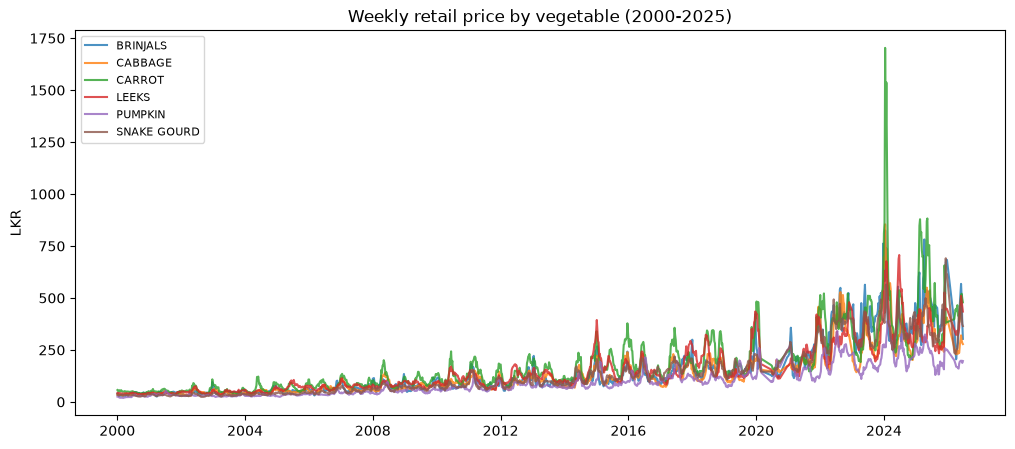

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for veg, grp in prices.groupby('vegetable'):
    ax.plot(grp['week_start'], grp['retail_price'], label=veg, alpha=0.8)
ax.set_title('Weekly retail price by vegetable (2000-2025)')
ax.set_ylabel('LKR')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## Fuel price trend

Diesel is the transport-cost driver used as an exogenous feature (petrol was dropped from the raw dataset - it isn't part of the vegetable supply chain).

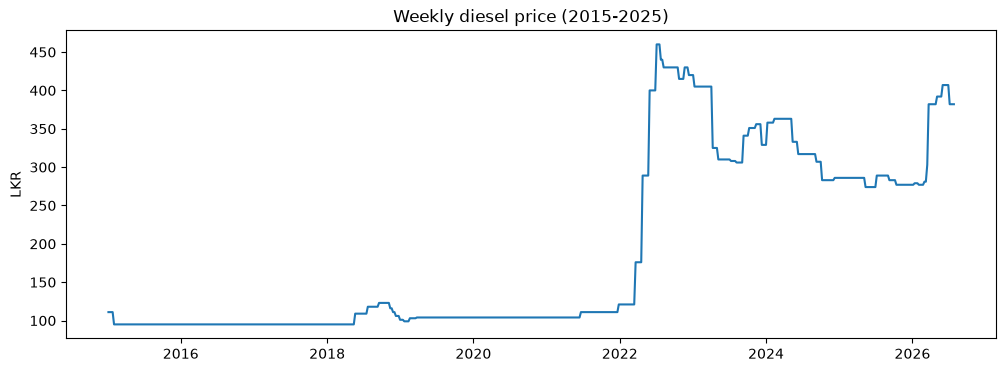

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fuel['date'], fuel['diesel_price'])
ax.set_title('Weekly diesel price (2015-2025)')
ax.set_ylabel('LKR')
plt.show()

## Weather: representative districts per the mapping in `configs/config.yaml`

Several vegetables share the same growing district (e.g. carrot/leeks/cabbage all map to Nuwara Eliya), so plotting one line *per vegetable* draws identical lines directly on top of each other and hides all but one. Grouping by district instead, with every vegetable that maps to it in the label, shows all 6 vegetables without any hidden overlap.

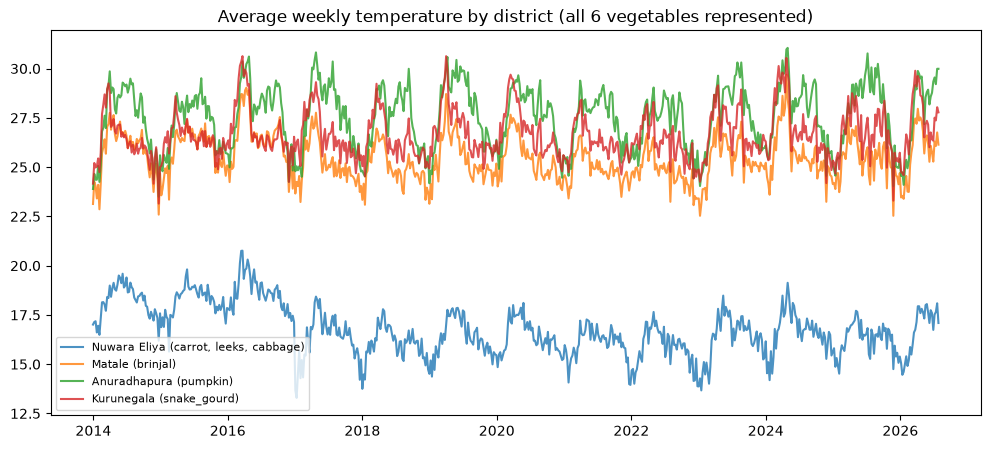

In [6]:
from collections import defaultdict

district_map = config['weather_district_map']
vegs_by_district = defaultdict(list)
for veg, district in district_map.items():
    vegs_by_district[district].append(veg)

fig, ax = plt.subplots(figsize=(12, 5))
for district, vegs in vegs_by_district.items():
    d = weather[weather['district'] == district]
    ax.plot(d['week_start_date'], d['average_temperature'], label=f"{district} ({', '.join(vegs)})", alpha=0.8)
ax.set_title('Average weekly temperature by district (all 6 vegetables represented)')
ax.legend(fontsize=8)
plt.show()

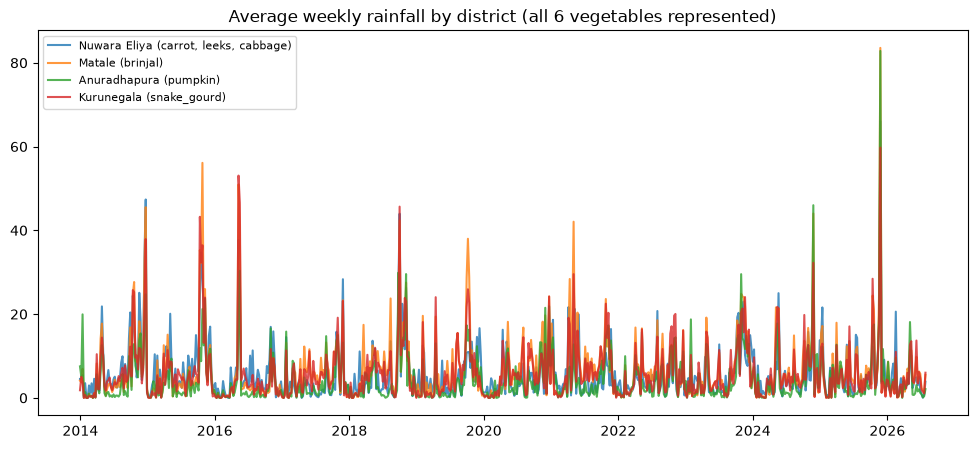

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for district, vegs in vegs_by_district.items():
    d = weather[weather['district'] == district]
    ax.plot(d['week_start_date'], d['average_rainfall'], label=f"{district} ({', '.join(vegs)})", alpha=0.8)
ax.set_title('Average weekly rainfall by district (all 6 vegetables represented)')
ax.legend(fontsize=8)
plt.show()

## Processed per-vegetable datasets (after `build_dataset.py` merges all 3 sources)

In [8]:
carrot = pd.read_csv('../data/processed/carrot.csv', parse_dates=['date'])
carrot.describe()

# get wholesale and retial for each vegetable
cabbage = pd.read_csv('../data/processed/cabbage.csv', parse_dates=['date'])
snakeGourd = pd.read_csv('../data/processed/snake_gourd.csv', parse_dates=['date'])
pumpking = pd.read_csv('../data/processed/pumpkin.csv', parse_dates=['date'])
leeks = pd.read_csv('../data/processed/leeks.csv', parse_dates=['date'])
brinjal = pd.read_csv('../data/processed/brinjal.csv', parse_dates=['date'])

# cabbage.describe()
# snakeGourd.describe()
# pumpking.describe()
# leeks.describe()
# brinjal.describe()

datasets = {
    "Carrot": carrot,
    "Cabbage": cabbage,
    "Snake Gourd": snakeGourd,
    "Pumpkin": pumpking,
    "Leeks": leeks,
    "Brinjal": brinjal
}

summary = pd.concat(
    {name: df.describe().round(1) for name, df in datasets.items()},
    axis=1
)
summary


Carrot                               \
                             date retail_price wholesale_price   
count                         583        583.0           583.0   
mean   2020-08-14 12:38:17.084048        290.4           185.9   
min           2015-01-05 00:00:00         94.0            37.9   
25%           2017-10-26 12:00:00        174.1            97.8   
50%           2020-08-10 00:00:00        238.7           136.7   
75%           2023-06-01 12:00:00        378.2           240.5   
max           2026-06-22 00:00:00       1703.3          1395.8   
std                           NaN        174.1           143.9   

                                                         \
      average_temperature average_rainfall diesel_price   
count               583.0            583.0        583.0   
mean                 16.7              5.5        185.1   
min                  13.3              0.0         95.0   
25%                  15.9              1.7         95.0   
50%                  16.6              3.6        104.0   
75%                  17.5              7.0        289.0   
max                  20.8             66.0        460.0   
std                   1.2              6.2        117.1   

                          Cabbage                               \
                             date retail_price wholesale_price   
count                         583        583.0           583.0   
mean   2020-08-14 12:38:17.084048        220.7           106.8   
min           2015-01-05 00:00:00         71.5             5.8   
25%           2017-10-26 12:00:00        139.8            40.9   
50%           2020-08-10 00:00:00        183.5            80.0   
75%           2023-06-01 12:00:00        277.4           134.1   
max           2026-06-22 00:00:00        854.3           553.0   
std                           NaN        121.1            92.3   

                           ...           Leeks                      \
      average_temperature  ... wholesale_price average_temperature   
count               583.0  ...           583.0               583.0   
mean                 16.7  ...           133.2                16.7   
min                  13.3  ...            20.8                13.3   
25%                  15.9  ...            70.0                15.9   
50%                  16.6  ...           110.0                16.6   
75%                  17.5  ...           180.5                17.5   
max                  20.8  ...           507.0                20.8   
std                   1.2  ...            83.8                 1.2   

                                                        Brinjal               \
      average_rainfall diesel_price                        date retail_price   
count            583.0        583.0                         583        583.0   
mean               5.5        185.1  2020-08-14 12:38:17.084048        252.7   
min                0.0         95.0         2015-01-05 00:00:00         75.0   
25%                1.7         95.0         2017-10-26 12:00:00        134.8   
50%                3.6        104.0         2020-08-10 00:00:00        201.3   
75%                7.0        289.0         2023-06-01 12:00:00        360.3   
max               66.0        460.0         2026-06-22 00:00:00        825.2   
std                6.2        117.1                         NaN        144.9   

                                                                         
      wholesale_price average_temperature average_rainfall diesel_price  
count           583.0               583.0            583.0        583.0  
mean            156.4                25.4              6.6        185.1  
min              14.3                22.5              0.0         95.0  
25%              70.2                24.7              1.7         95.0  
50%             118.3                25.3              4.2        104.0  
75%             226.0                26.3              8.4        289.0  
max             575.

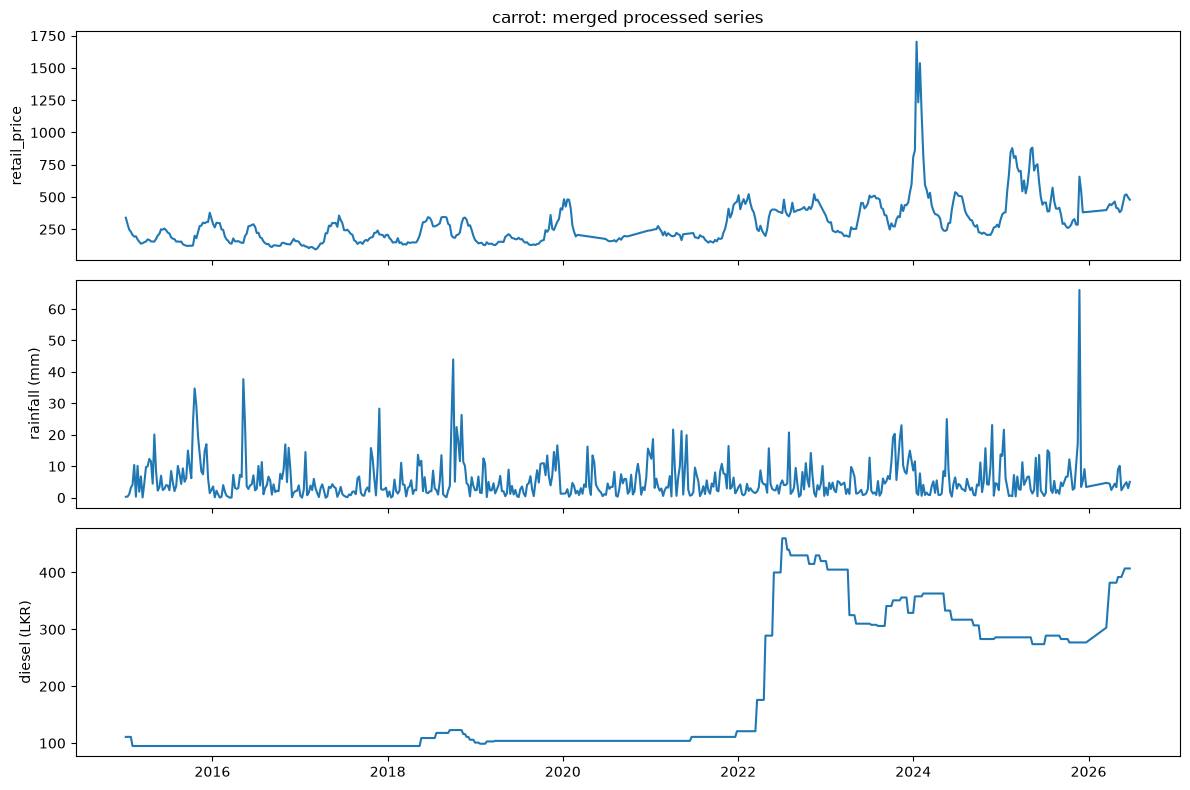

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(carrot['date'], carrot['retail_price']); axes[0].set_ylabel('retail_price')
axes[1].plot(carrot['date'], carrot['average_rainfall']); axes[1].set_ylabel('rainfall (mm)')
axes[2].plot(carrot['date'], carrot['diesel_price']); axes[2].set_ylabel('diesel (LKR)')
axes[0].set_title('carrot: merged processed series')
plt.tight_layout(); plt.show()

## Correlation between exogenous drivers and price

In [10]:
carrot[['retail_price', 'average_rainfall', 'average_temperature', 'diesel_price']].corr()

,retail_price,average_rainfall,average_temperature,diesel_price
retail_price,1.000000,-0.034906,-0.249615,0.572935
average_rainfall,-0.034906,1.000000,-0.000541,0.011368
average_temperature,-0.249615,-0.000541,1.000000,-0.205407
diesel_price,0.572935,0.011368,-0.205407,1.000000


---
# Pattern & Trend Analysis

The sections above show the raw series. This section characterizes *how* each vegetable's price behaves: trend/seasonality decomposition, whether volatility has changed over time (motivates why SARIMAX struggles on the recent holdout year - see CLAUDE.md), autocorrelation structure (motivates the SARIMAX order and the lag features in `feature_engineering.py`), and which exogenous lag actually correlates most with price.

## Seasonal decomposition (STL)

Decomposes each vegetable's retail price into trend, (52-week) seasonal, and residual components.

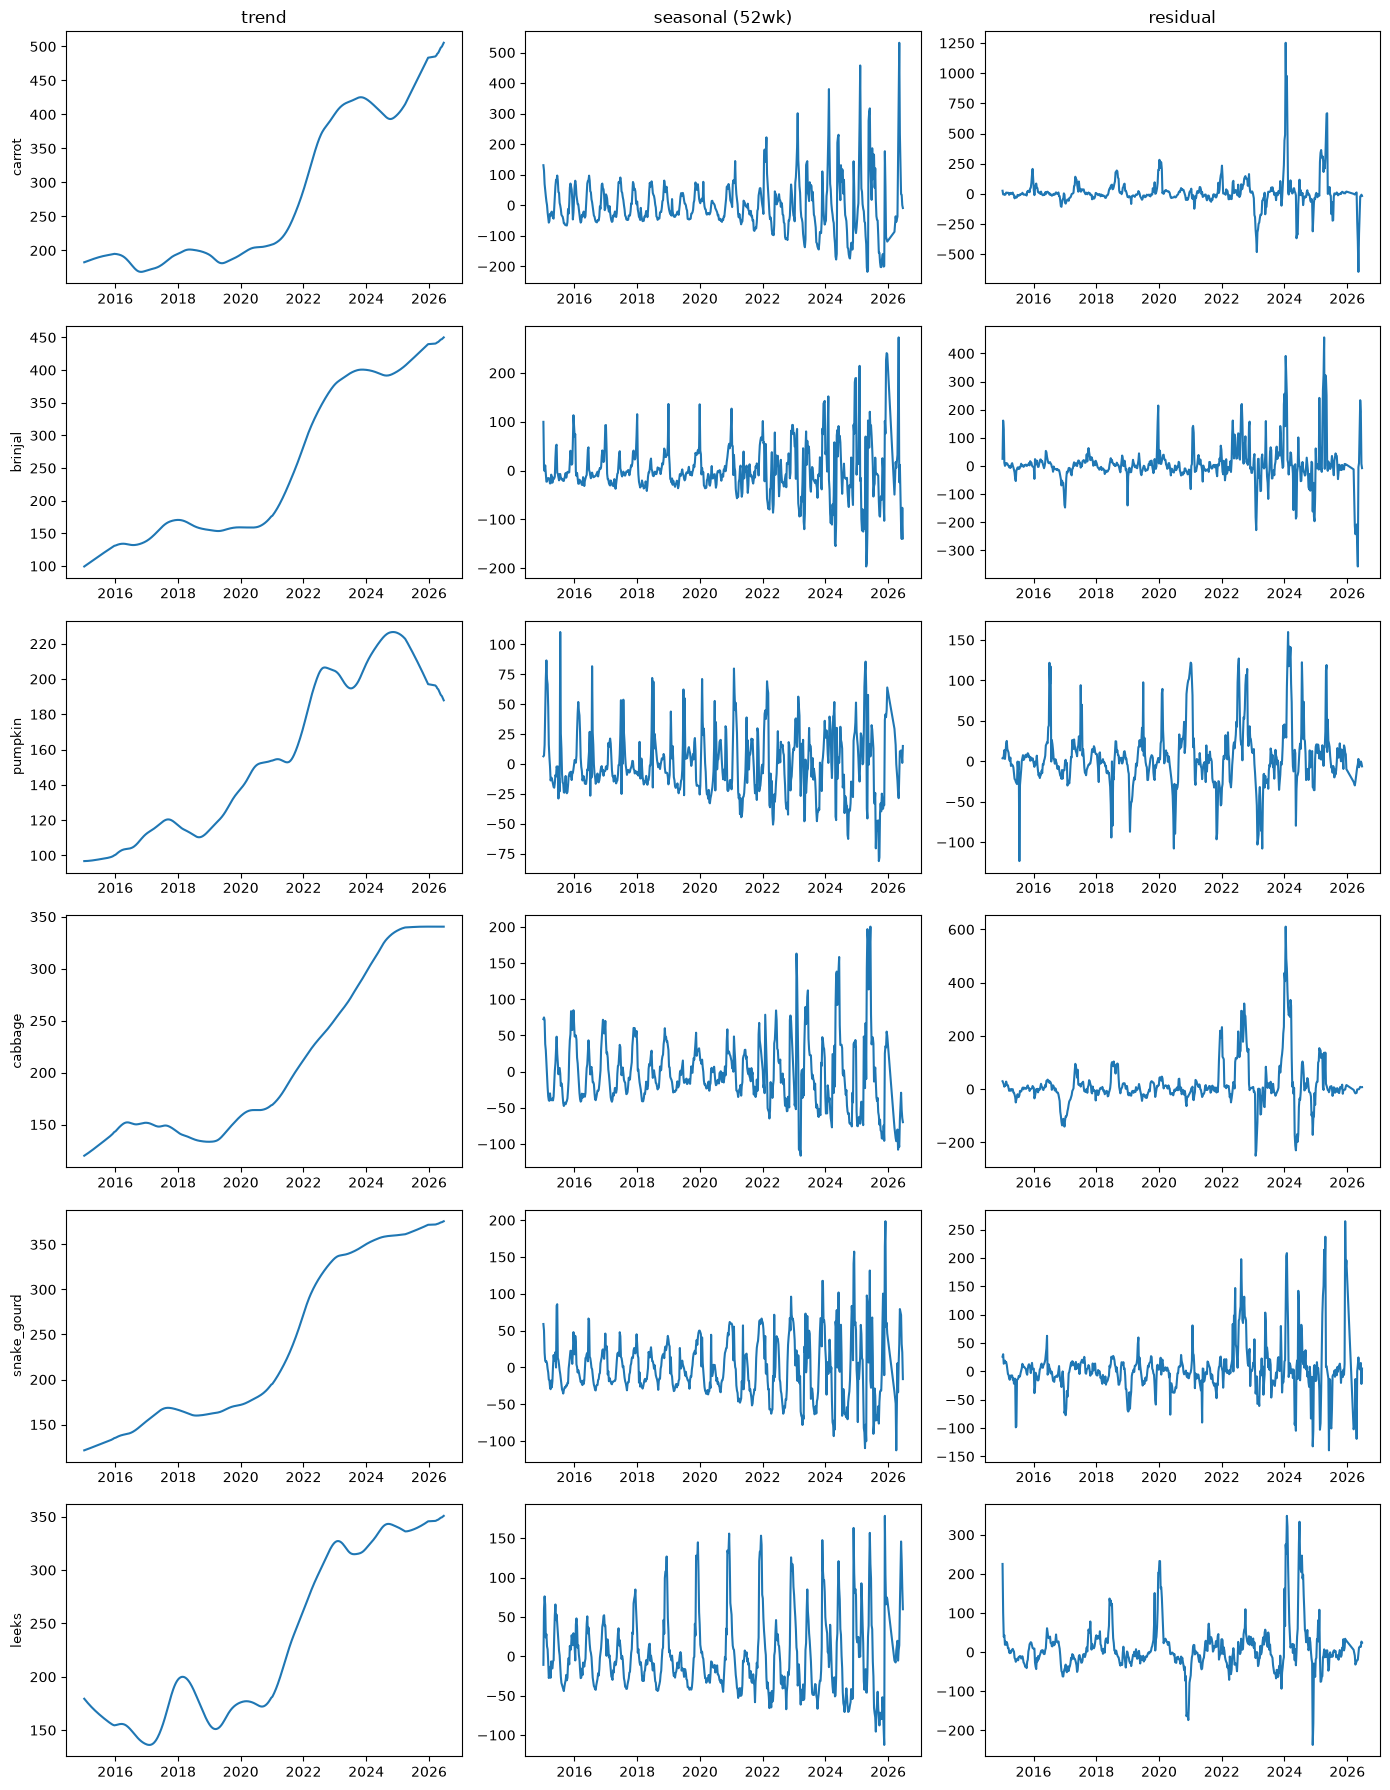

In [11]:
from statsmodels.tsa.seasonal import STL

vegetables = config['vegetables']
fig, axes = plt.subplots(len(vegetables), 3, figsize=(14, 3 * len(vegetables)))

for i, veg in enumerate(vegetables):
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date']).set_index('date')
    result = STL(df['retail_price'], period=52, robust=True).fit()
    axes[i, 0].plot(result.trend); axes[i, 0].set_ylabel(veg, fontsize=9)
    axes[i, 1].plot(result.seasonal)
    axes[i, 2].plot(result.resid)
    if i == 0:
        axes[i, 0].set_title('trend'); axes[i, 1].set_title('seasonal (52wk)'); axes[i, 2].set_title('residual')

plt.tight_layout(); plt.show()

## Year-over-year seasonality

Overlaying each calendar year's price curve (by week-of-year) shows whether the seasonal pattern is consistent, and which years were anomalous.

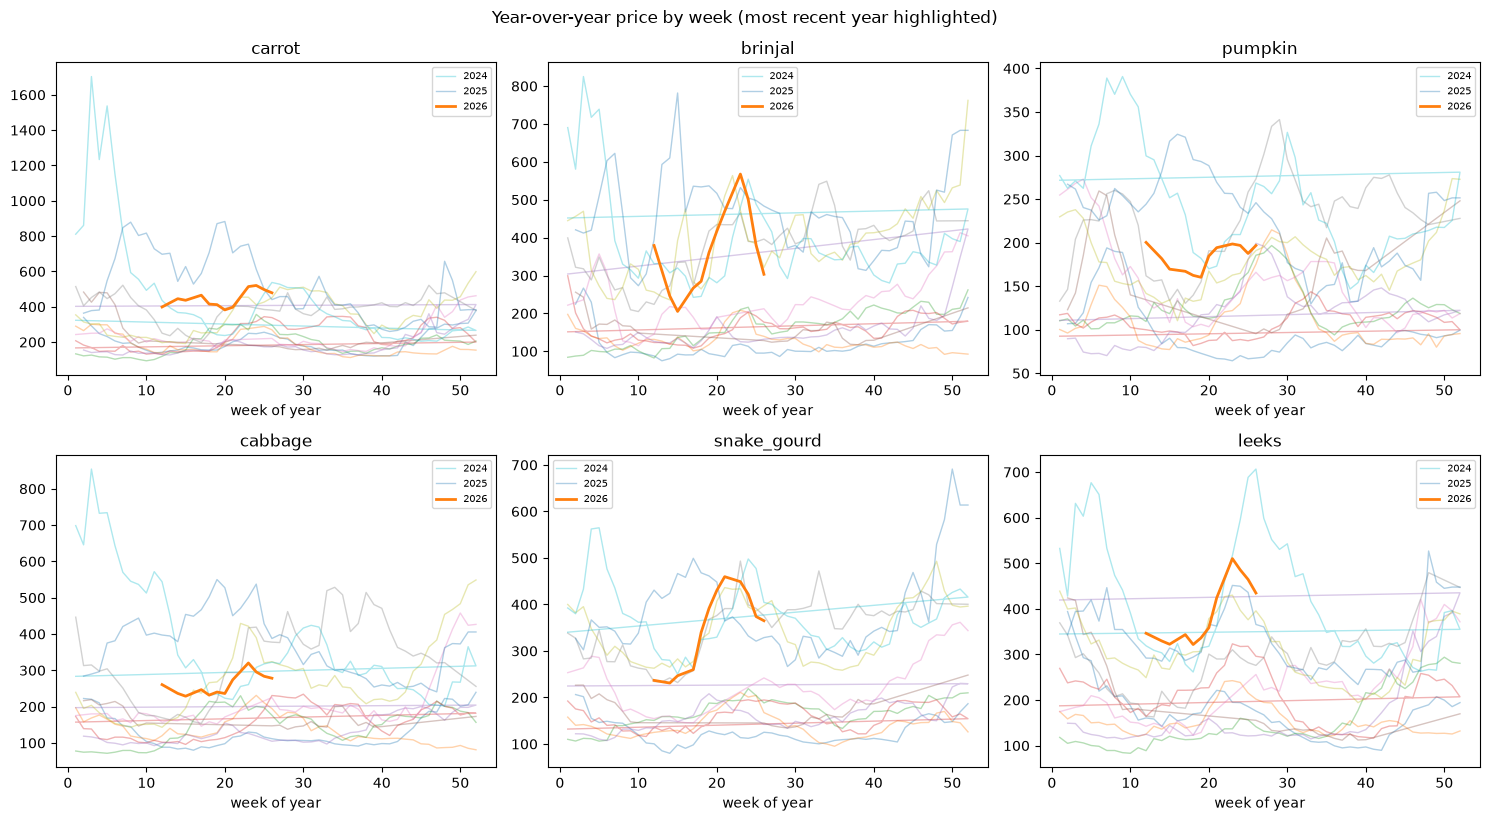

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, veg in zip(axes.flat, vegetables):
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    df['year'] = df['date'].dt.year
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    for year, grp in df.groupby('year'):
        alpha = 1.0 if year == df['year'].max() else 0.35
        lw = 2 if year == df['year'].max() else 1
        ax.plot(grp['week_of_year'], grp['retail_price'], alpha=alpha, linewidth=lw, label=str(year) if year >= 2024 else None)
    ax.set_title(veg); ax.set_xlabel('week of year')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.suptitle('Year-over-year price by week (most recent year highlighted)', y=1.02)
plt.show()

## Rolling volatility

12-week rolling standard deviation of retail price. A rising line means the market has gotten *more* volatile recently - directly relevant to why SARIMAX's holdout R² is negative on every vegetable (see CLAUDE.md's Project status).

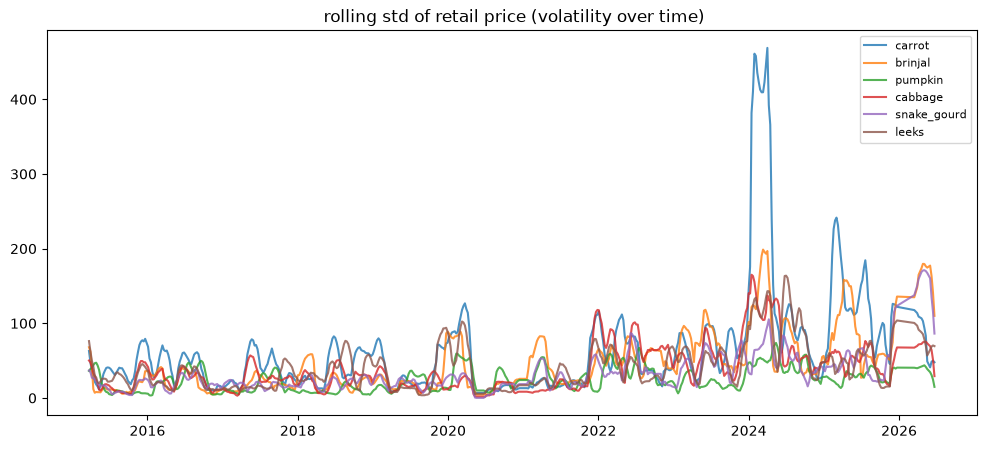

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
for veg in vegetables:
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    rolling_std = df['retail_price'].rolling(12).std()
    ax.plot(df['date'], rolling_std, label=veg, alpha=0.8)
ax.set_title(' rolling std of retail price (volatility over time)')
ax.legend(fontsize=8)
plt.show()

## Stationarity (Augmented Dickey-Fuller)

Tests each vegetable's retail price for stationarity, on the raw series and on the first difference - the empirical justification for `d=1` in the SARIMAX order (`configs/config.yaml`'s `order_by_vegetable`, see CLAUDE.md's SARIMAX gotchas). Null hypothesis of the ADF test is "series has a unit root" (non-stationary); a p-value below 0.05 rejects that, i.e. stationary.

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_row(series):
    stat, pvalue, *_ = adfuller(series.dropna(), autolag='AIC')
    return stat, pvalue

rows = []
for veg in vegetables:
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    raw_stat, raw_p = adf_row(df['retail_price'])
    diff_stat, diff_p = adf_row(df['retail_price'].diff())
    rows.append({
        'vegetable': veg,
        'adf_stat_raw': raw_stat, 'p_value_raw': raw_p, 'stationary_raw (p<0.05)': raw_p < 0.05,
        'adf_stat_diff': diff_stat, 'p_value_diff': diff_p, 'stationary_diff (p<0.05)': diff_p < 0.05,
    })

stationarity = pd.DataFrame(rows).set_index('vegetable')
stationarity

,adf_stat_raw,p_value_raw,stationary_raw (p<0.05),adf_stat_diff,p_value_diff,stationary_diff (p<0.05)
vegetable,,,,,,
carrot,-2.458851,0.125810,False,-9.152829,2.658013e-15,True
brinjal,-1.507605,0.529746,False,-8.805667,2.055119e-14,True
pumpkin,-3.122240,0.024950,True,-8.253514,5.312388e-13,True
cabbage,-2.131087,0.232200,False,-9.037352,5.245475e-15,True
snake_gourd,-0.725637,0.839997,False,-7.978581,2.660984e-12,True
leeks,-1.859859,0.351174,False,-9.939888,2.681767e-17,True


## Autocorrelation (ACF/PACF)

On the differenced series (removing trend), for carrot - motivates the SARIMAX order in `configs/config.yaml` and the lag features in `feature_engineering.py`.

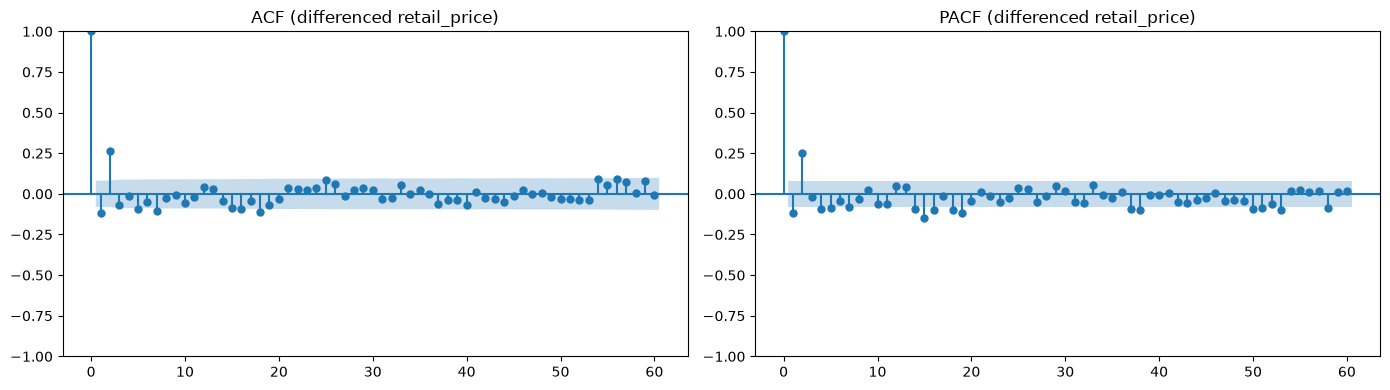

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

carrot_diff = carrot['retail_price'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(carrot_diff, lags=60, ax=axes[0])
plot_pacf(carrot_diff, lags=60, ax=axes[1])
axes[0].set_title('ACF (differenced retail_price)')
axes[1].set_title('PACF (differenced retail_price)')
plt.tight_layout(); plt.show()

## Which exogenous lag correlates most with price?

Correlates retail price against rainfall/temperature/diesel at lags 0-8 weeks, per vegetable - tells us whether the 1-week lag used in `feature_engineering.py` is actually the strongest signal, or whether a longer lag would serve better.

In [16]:
lags = range(0, 9)
rows = []
for veg in vegetables:
    df = pd.read_csv(f'../data/processed/{veg}.csv', parse_dates=['date'])
    for lag in lags:
        row = {'vegetable': veg, 'lag_weeks': lag}
        for driver in ['average_rainfall', 'average_temperature', 'diesel_price']:
            row[driver] = df['retail_price'].corr(df[driver].shift(lag))
        rows.append(row)
lag_corr = pd.DataFrame(rows)
best_lag = lag_corr.loc[lag_corr.groupby('vegetable')['diesel_price'].apply(lambda s: s.abs().idxmax())]
print('Strongest |correlation| lag for diesel_price, per vegetable:')
best_lag[['vegetable', 'lag_weeks', 'diesel_price']]

Strongest |correlation| lag for diesel_price, per vegetable:


,vegetable,lag_weeks,diesel_price
11,brinjal,2,0.790216
28,cabbage,1,0.702134
0,carrot,0,0.572935
53,leeks,8,0.704611
18,pumpkin,0,0.672482
37,snake_gourd,1,0.825777


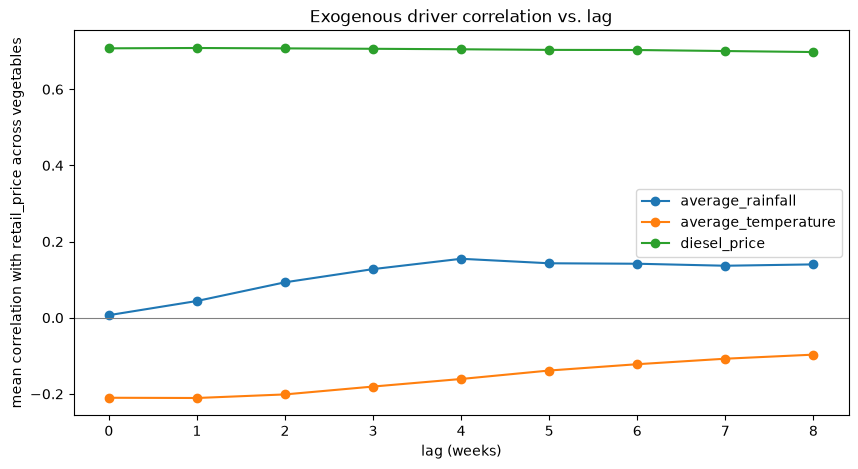

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for driver in ['average_rainfall', 'average_temperature', 'diesel_price']:
    avg_by_lag = lag_corr.groupby('lag_weeks')[driver].mean()
    ax.plot(avg_by_lag.index, avg_by_lag.values, marker='o', label=driver)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('lag (weeks)'); ax.set_ylabel('mean correlation with retail_price across vegetables')
ax.set_title('Exogenous driver correlation vs. lag')
ax.legend()
plt.show()